In [6]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import scipy.io
from matplotlib import rcParams
from matplotlib import colors
import seaborn as sb
import gc

# sc.settings.verbosity = 3
# sc.logging.print_versions()

### Analyze data

In [3]:
adata = sc.read('/h/am/EX_M/datasets/scRNA/pbmc68k/pbmc68k.h5ad')
adata

AnnData object with n_obs × n_vars = 68579 × 17789
    obs: 'celltype'
    var: 'gene_ids', 'n_cells'
    uns: 'log1p'
    layers: 'counts'

In [4]:
adata.var

,gene_ids,n_cells
AL627309.1,ENSG00000237683,64
AP006222.2,ENSG00000228463,4
RP11-206L10.2,ENSG00000228327,91
RP11-206L10.9,ENSG00000237491,55
FAM87B,ENSG00000177757,7
...,...,...
AC011841.1,ENSG00000212884,23
AL354822.1,ENSG00000215615,20
KIR2DL2,ENSG00000215764,20
PNRC2-1,ENSG00000215700,1833


/h/am/.local/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


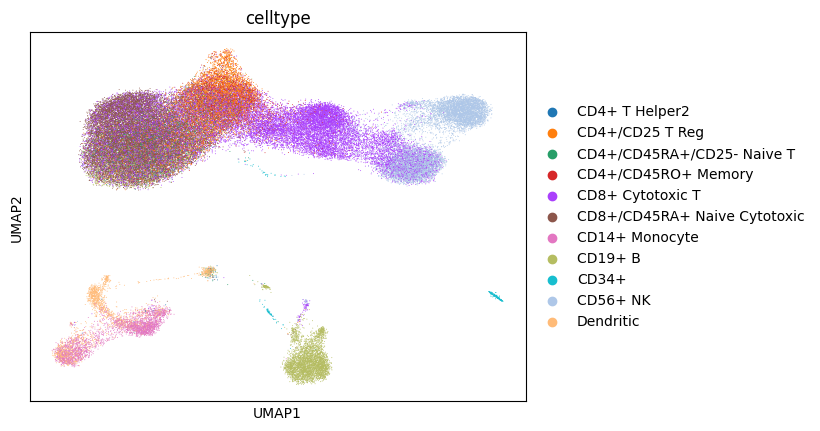

In [5]:
sc.pp.highly_variable_genes(adata, n_top_genes=4000)
sc.pp.pca(adata, n_comps=50, use_highly_variable=True, svd_solver='arpack')
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['celltype'], ncols=2)

In [7]:
train = sc.read('/h/am/EX_M/datasets/scRNA/pbmc68k/seed_32/scFoundation/train/pbmc68k_train_processed.h5ad')
train

AnnData object with n_obs × n_vars = 54840 × 19264
    obs: 'celltype', 'n_genes', 'set', 'ID', 'label'
    uns: 'hvg', 'log1p'

In [8]:
test = sc.read('/h/am/EX_M/datasets/scRNA/pbmc68k/seed_32/scFoundation/test/pbmc68k_test_processed.h5ad')
test

AnnData object with n_obs × n_vars = 6856 × 19264
    obs: 'celltype', 'n_genes', 'set', 'ID', 'label'
    uns: 'hvg', 'log1p'

In [9]:
val = sc.read('/h/am/EX_M/datasets/scRNA/pbmc68k/seed_32/scFoundation/validation/pbmc68k_val_processed.h5ad')
val

AnnData object with n_obs × n_vars = 6855 × 19264
    obs: 'celltype', 'n_genes', 'set', 'ID', 'label'
    uns: 'hvg', 'log1p'

In [10]:
train.obs['celltype'].value_counts()

celltype
CD8+ Cytotoxic T                16617
CD8+/CD45RA+ Naive Cytotoxic    13329
CD56+ NK                         7021
CD4+/CD25 T Reg                  4949
CD19+ B                          4721
CD4+/CD45RO+ Memory              2448
CD14+ Monocyte                   2290
Dendritic                        1679
CD4+/CD45RA+/CD25- Naive T       1497
CD34+                             211
CD4+ T Helper2                     78
Name: count, dtype: int64

In [11]:
test.obs['celltype'].value_counts()

celltype
CD8+ Cytotoxic T                2078
CD8+/CD45RA+ Naive Cytotoxic    1667
CD56+ NK                         878
CD4+/CD25 T Reg                  619
CD19+ B                          590
CD4+/CD45RO+ Memory              306
CD14+ Monocyte                   286
Dendritic                        210
CD4+/CD45RA+/CD25- Naive T       187
CD34+                             26
CD4+ T Helper2                     9
Name: count, dtype: int64

In [12]:
val.obs['celltype'].value_counts()

celltype
CD8+ Cytotoxic T                2077
CD8+/CD45RA+ Naive Cytotoxic    1666
CD56+ NK                         877
CD4+/CD25 T Reg                  619
CD19+ B                          590
CD4+/CD45RO+ Memory              306
CD14+ Monocyte                   286
Dendritic                        210
CD4+/CD45RA+/CD25- Naive T       187
CD34+                             27
CD4+ T Helper2                    10
Name: count, dtype: int64